# 一维 FNO 学习 Poisson 解算子（对应书中 §11.4）

$$-u''=f,\quad x\in[0,1),\ \text{周期边界},\qquad
v_{l+1}=\sigma\big(Wv_l+\mathcal{F}^{-1}(R_\phi\cdot\mathcal{F}v_l)\big)$$

In [1]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

In [2]:
S, K = 128, 12
k_all = torch.fft.fftfreq(S, 1 / S)

def make_data(n):
    coef = torch.randn(n, K, 2) / torch.arange(1, K + 1)[None, :, None]
    fh = torch.zeros(n, S, dtype=torch.cfloat)
    fh[:, 1:K + 1] = torch.complex(coef[..., 0], coef[..., 1])
    fh[:, -K:] = fh[:, 1:K + 1].flip(1).conj()
    f = torch.fft.ifft(fh, norm="forward").real
    uh = torch.zeros_like(fh)
    kk = (2 * torch.pi * k_all) ** 2
    uh[:, 1:] = fh[:, 1:] / kk[1:]
    u = torch.fft.ifft(uh, norm="forward").real
    return f, u

class SpectralConv1d(nn.Module):
    def __init__(self, width, modes):
        super().__init__()
        self.modes = modes
        scale = 1 / width ** 2
        self.w = nn.Parameter(scale * torch.randn(width, width, modes, dtype=torch.cfloat))

    def forward(self, v):
        vh = torch.fft.rfft(v)
        out = torch.zeros_like(vh)
        out[:, :, :self.modes] = torch.einsum("bim,iom->bom", vh[:, :, :self.modes], self.w)
        return torch.fft.irfft(out, n=v.shape[-1])

class FNO1d(nn.Module):
    def __init__(self, width=32, modes=16, layers=4):
        super().__init__()
        self.lift = nn.Linear(2, width)
        self.spec = nn.ModuleList([SpectralConv1d(width, modes) for _ in range(layers)])
        self.lin = nn.ModuleList([nn.Conv1d(width, width, 1) for _ in range(layers)])
        self.proj = nn.Sequential(nn.Linear(width, 64), nn.GELU(), nn.Linear(64, 1))

    def forward(self, f):
        x = torch.linspace(0, 1, f.shape[-1]).expand(f.shape[0], -1)
        v = self.lift(torch.stack([f, x], dim=-1)).permute(0, 2, 1)
        for s, l in zip(self.spec, self.lin):
            v = torch.nn.functional.gelu(s(v) + l(v))
        return self.proj(v.permute(0, 2, 1)).squeeze(-1)

In [3]:
model = FNO1d()
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
sched = torch.optim.lr_scheduler.StepLR(opt, 1000, 0.5)

f_test, u_test = make_data(200)
for epoch in range(3001):
    f, u = make_data(64)
    loss = ((model(f) - u) ** 2).mean()
    opt.zero_grad()
    loss.backward()
    opt.step()
    sched.step()
    if epoch % 500 == 0:
        with torch.no_grad():
            rel = (model(f_test) - u_test).norm() / u_test.norm()
        print(f"epoch {epoch:5d}   loss = {loss.item():.3e}   test rel-L2 = {rel:.3e}")

epoch     0   loss = 1.565e-02   test rel-L2 = 1.977e+00


epoch   500   loss = 7.295e-08   test rel-L2 = 3.914e-03


epoch  1000   loss = 2.180e-08   test rel-L2 = 2.361e-03


epoch  1500   loss = 1.428e-08   test rel-L2 = 2.004e-03


epoch  2000   loss = 9.008e-09   test rel-L2 = 2.218e-03


epoch  2500   loss = 7.107e-09   test rel-L2 = 1.710e-03


epoch  3000   loss = 9.859e-09   test rel-L2 = 1.619e-03


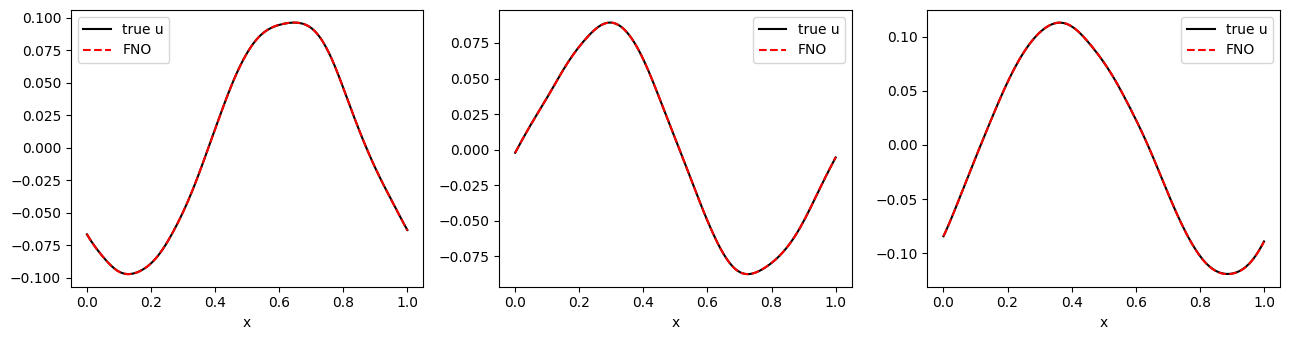

In [4]:
x = torch.linspace(0, 1, S)
with torch.no_grad():
    pred = model(f_test[:3])

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for i, ax in enumerate(axes):
    ax.plot(x, u_test[i], "k-", label="true u")
    ax.plot(x, pred[i], "r--", label="FNO")
    ax.set_xlabel("x"); ax.legend()
plt.tight_layout(); plt.show()